In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
shimla = pd.read_csv("shimla_urban.csv")
goa = pd.read_csv("Goa.csv")
delhi = pd.read_csv("Delhi.csv")
jaisalmer = pd.read_csv("Jaisalmer.csv")

In [4]:
print("Shimla :", shimla.shape)
print("Delhi :", delhi.shape)
print("Goa :", goa.shape)
print("Jaisalmer :", jaisalmer.shape)

Shimla : (61392, 12)
Delhi : (61392, 12)
Goa : (61392, 12)
Jaisalmer : (61392, 12)


In [5]:
summary = pd.DataFrame({
    "Location":[
        "shimla",
        "Delhi",
        "Goa",
        "Jaisalmer"
    ],

    "Climate":[
        "Mountain",
        "Urban Continental",
        "Coastal Tropical",
        "Desert"
    ]
})

summary

,Location,Climate
0,shimla,Mountain
1,Delhi,Urban Continental
2,Goa,Coastal Tropical
3,Jaisalmer,Desert


In [6]:
irradiance = pd.DataFrame({
    "Location":[
        "Shimla",
        "Delhi",
        "Goa",
        "Jaisalmer"
    ],

    "Mean_Irradiance":[
        shimla["ALLSKY_SFC_SW_DWN"].mean(),
        delhi["ALLSKY_SFC_SW_DWN"].mean(),
        goa["ALLSKY_SFC_SW_DWN"].mean(),
        jaisalmer["ALLSKY_SFC_SW_DWN"].mean()
    ]
})

irradiance

,Location,Mean_Irradiance
0,Shimla,191.188567
1,Delhi,194.387016
2,Goa,212.641006
3,Jaisalmer,231.656386


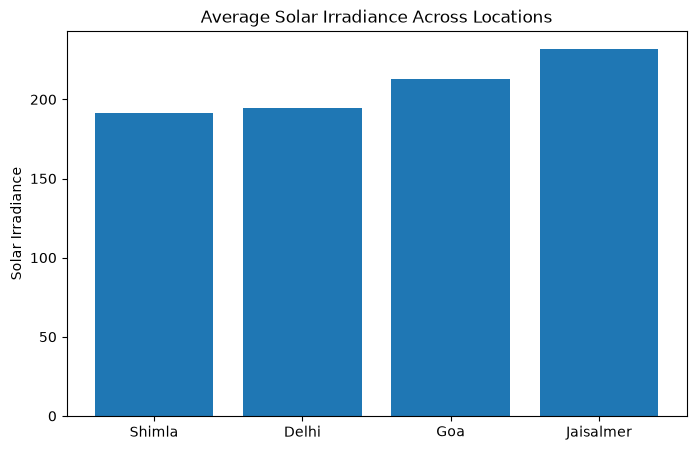

In [7]:
plt.figure(figsize=(8,5))

plt.bar(
    irradiance["Location"],
    irradiance["Mean_Irradiance"]
)

plt.title("Average Solar Irradiance Across Locations")

plt.ylabel("Solar Irradiance")

plt.show()

In [8]:
for df in [shimla, delhi, goa, jaisalmer]:

    df["month"] = df["MO"]

shimla_month = shimla.groupby("month")[
    "ALLSKY_SFC_SW_DWN"
].mean()

delhi_month = delhi.groupby("month")[
    "ALLSKY_SFC_SW_DWN"
].mean()

goa_month = goa.groupby("month")[
    "ALLSKY_SFC_SW_DWN"
].mean()

jaisalmer_month = jaisalmer.groupby("month")[
    "ALLSKY_SFC_SW_DWN"
].mean()

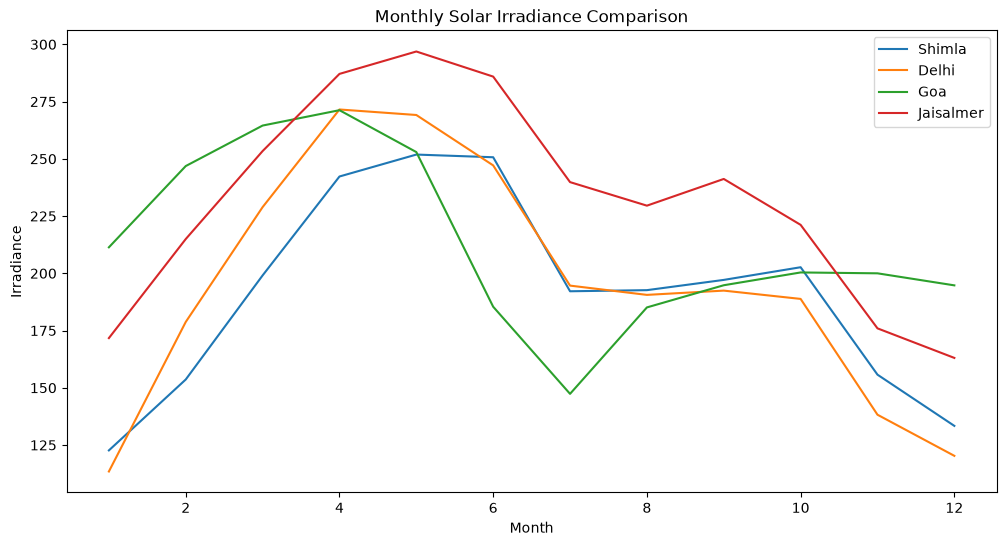

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    shimla_month.index,
    shimla_month.values,
    label="Shimla"
)

plt.plot(
    delhi_month.index,
    delhi_month.values,
    label="Delhi"
)

plt.plot(
    goa_month.index,
    goa_month.values,
    label="Goa"
)

plt.plot(
    jaisalmer_month.index,
    jaisalmer_month.values,
    label="Jaisalmer"
)

plt.legend()

plt.title(
    "Monthly Solar Irradiance Comparison"
)

plt.xlabel("Month")

plt.ylabel("Irradiance")

plt.show()

In [10]:
results = pd.DataFrame({

    "Location":[
        "Shimla",
        "Jaisalmer",
        "Goa",
        "Delhi"
    ],

    "R2_1h":[
        0.976635,
        0.994966,
        0.985567,
        0.979480
    ],

    "RMSE_1h":[
        38.073491,
        20.353479,
        33.748703,
        36.524859
    ],

    "MAE_1h":[
        25.452072,
        14.549200  ,
        21.641621,
        23.109149
    ]
})

results

,Location,R2_1h,RMSE_1h,MAE_1h
0,Shimla,0.976635,38.073491,25.452072
1,Jaisalmer,0.994966,20.353479,14.549200
2,Goa,0.985567,33.748703,21.641621
3,Delhi,0.979480,36.524859,23.109149


Hybrid MAE : 33.926186201660386
Hybrid RMSE : 47.75698015650622
Hybrid R2 : 0.9723233492397209
    YEAR  MO  DY  HR  ALLSKY_SFC_SW_DWN    T2M   RH2M     PS  WS10M  \
7   2019   1   1   7              34.40   9.85  24.34  99.64   1.96   
8   2019   1   1   8             201.65  12.79  20.38  99.74   1.74   
9   2019   1   1   9             387.85  15.25  17.19  99.76   2.06   
10  2019   1   1  10             540.03  18.34  14.12  99.70   1.85   
11  2019   1   1  11             635.28  22.06  10.48  99.57   1.16   

    ALLSKY_KT  PRECTOTCORR    SZA            datetime  hour  month  dayofyear  \
7        0.34          0.0  85.92 2019-01-01 07:00:00     7      1          1   
8        0.55          0.0  74.76 2019-01-01 08:00:00     8      1          1   
9        0.64          0.0  64.67 2019-01-01 09:00:00     9      1          1   
10       0.70          0.0  56.51 2019-01-01 10:00:00    10      1          1   
11       0.72          0.0  51.22 2019-01-01 11:00:00    11      1       

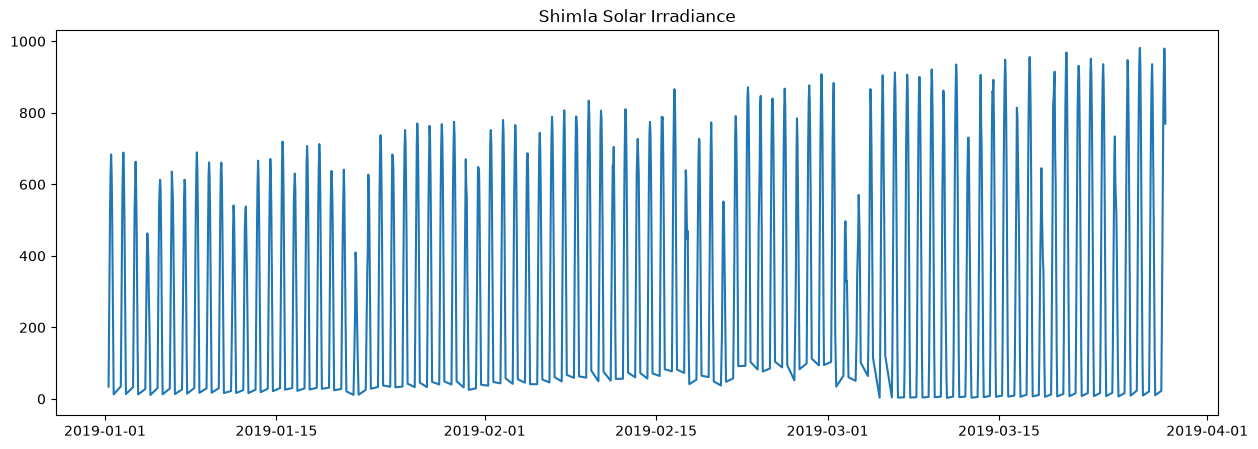

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(
    y_test_aligned,
    hybrid_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_aligned,
        hybrid_pred
    )
)

r2 = r2_score(
    y_test_aligned,
    hybrid_pred
)

print("Hybrid MAE :", mae)
print("Hybrid RMSE :", rmse)
print("Hybrid R2 :", r2)


print(df.head())
print(df.shape)


plt.figure(figsize=(15,5))

plt.plot(
    df["datetime"][:1000],
    df["ALLSKY_SFC_SW_DWN"][:1000]
)

plt.title("Shimla Solar Irradiance")
plt.show()

In [17]:
import pandas as pd

comparison = pd.DataFrame({

    "Model":[
        "XGBoost",
        "Hybrid XGB-LSTM"
    ],

    "MAE":[
        14.310898471031752,
        33.926186201660386
    ],

    "RMSE":[
        19.960203388746933,
        47.75698015650622
    ],

    "R2":[
        0.9951646688526422,
        0.9723233492397209
    ]
})

print(comparison)

             Model        MAE       RMSE        R2
0          XGBoost  14.310898  19.960203  0.995165
1  Hybrid XGB-LSTM  33.926186  47.756980  0.972323


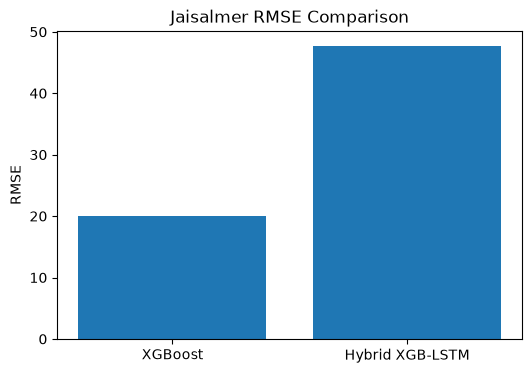

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Jaisalmer RMSE Comparison")
plt.ylabel("RMSE")

plt.show()

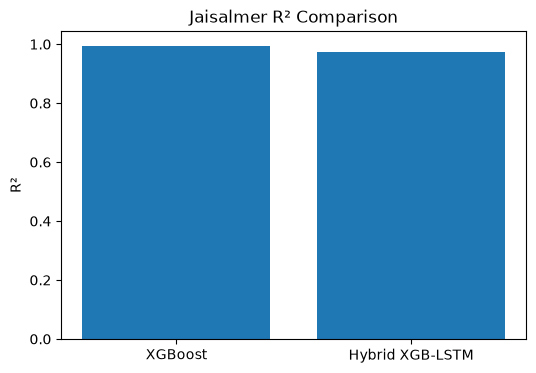

In [19]:
plt.figure(figsize=(6,4))

plt.bar(
    comparison["Model"],
    comparison["R2"]
)

plt.title("Jaisalmer R² Comparison")
plt.ylabel("R²")

plt.show()